# Notebook 3 — Dataset Generation + Train Your Own Model

**IMPORTANT before running:**
- Runtime → Change runtime type → **T4 GPU**
- This notebook **resumes automatically** if Colab disconnects — just re-run all cells
- Target: 50 proteins × 10 molecules = **500 molecules**

**How resuming works:** After each protein finishes, progress is saved to `dataset/done.json` and `dataset/pmdm_dataset.csv`. If Colab disconnects, run all cells again — already-done proteins are skipped instantly.

In [ ]:
# ═══════════════════════════════════════════════════════════
# RECOVERY CELL: Restore PMDM Environment
# ═══════════════════════════════════════════════════════════
import os, subprocess

# 1. Install micromamba if missing
if not os.path.exists('/content/micromamba/bin/micromamba'):
    print("Installing micromamba...")
    !curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba
    !mkdir -p /content/micromamba/bin && mv bin/micromamba /content/micromamba/bin/
    os.environ['MAMBA_ROOT_PREFIX'] = '/content/micromamba'

# 2. Recreate the pmdm environment (fast if already cached )
if not os.path.exists('/content/micromamba/envs/pmdm'):
    print("Recreating pmdm environment... (this may take 5-10 mins)")
    !/content/micromamba/bin/micromamba create -y -n pmdm -c conda-forge python=3.9 rdkit=2023.09.1 openbabel=3.1.1 pip

    # Install required AI libraries
    print("Installing AI libraries...")
    !/content/micromamba/bin/micromamba run -n pmdm pip install -q \
        torch==2.1.1 torchvision==0.16.1 torchaudio==2.1.1 \
        --index-url https://download.pytorch.org/whl/cu118

    !/content/micromamba/bin/micromamba run -n pmdm pip install -q \
        torch-geometric==2.4.0 torch-scatter==2.1.2+pt21cu118 \
        torch-sparse==0.6.18+pt21cu118 torch-cluster==1.6.3+pt21cu118 \
        torch-spline-conv==1.2.2+pt21cu118 \
        -f https://data.pyg.org/whl/torch-2.1.1+cu118.html

    !/content/micromamba/bin/micromamba run -n pmdm pip install -q \
        numpy==1.26.4 scipy pandas tqdm pyyaml einops biopython \
        networkx matplotlib easydict scikit-learn
    print("✓ Environment restored!" )
else:
    print("✓ pmdm environment already exists.")


Installing micromamba...
bin/micromamba
Recreating pmdm environment... (this may take 5-10 mins)
[+] 0.0s
[+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64   1%
conda-forge/noarch     4%[+] 0.3s
conda-forge/linux-64   7%
conda-forge/noarch    17%[+] 0.4s
conda-forge/linux-64  12%
conda-forge/noarch    22%[+] 0.5s
conda-forge/linux-64  16%
conda-forge/noarch    34%[+] 0.6s
conda-forge/linux-64  21%
conda-forge/noarch    45%[+] 0.7s
conda-forge/linux-64  28%
conda-forge/noarch    59%[+] 0.8s
conda-forge/linux-64  33%
conda-forge/noarch    69%[+] 0.9s
conda-forge/linux-64  36%
conda-forge/noarch    83%[+] 1.0s
conda-forge/linux-64  42%
conda-forge/noarch    87%conda-forge/noarch                                
[+] 1.1s
conda-forge/linux-64  51%[+] 1.2s
conda-forge/linux-64  59%[+] 1.3s
conda-forge/linux-64  59%[+] 1.4s
conda-forge/linux-64  59%[+] 1.5s
conda-forge/linux-64  60%[+] 1.6s
conda-forge/linux-64  60%[+] 1.7s
conda-forge/linux-64  60%[+] 1

In [ ]:
# ════════════════════════════════════════════════════
# CELL 1 — Mount Drive + verify everything exists
# ════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import pathlib, subprocess, json, time, os, urllib.request, csv, shutil

BASE       = pathlib.Path('/content/drive/MyDrive/PMDM')
REPO       = BASE / 'repo'
CKPT       = BASE / 'checkpoints' / '500.pt'
PYTHON     = '/content/micromamba/envs/pmdm/bin/python'
DATASET    = BASE / 'dataset'
POCKET_DIR = DATASET / 'pockets'
SDF_DIR    = DATASET / 'sdf_files'
MODEL_DIR  = BASE / 'my_model'
DEMO_DIR   = BASE / 'demo_outputs'

for d in [DATASET, POCKET_DIR, SDF_DIR, MODEL_DIR, DEMO_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Check GPU
r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                    '--format=csv,noheader'], capture_output=True, text=True)
print(f'GPU: {r.stdout.strip() if r.returncode==0 else "CPU only — switch to T4!"}')

# Check pmdm env
r = subprocess.run([PYTHON, '--version'], capture_output=True, text=True)
env_ok = r.returncode == 0
print(f'pmdm env : {r.stdout.strip() if env_ok else "MISSING — run Notebook 1 first!"}')
print(f'Checkpoint: {"found" if CKPT.exists() else "MISSING"}')
print(f'Repo      : {"found" if REPO.exists() else "MISSING"}')

# Resume status
done_keys = set(json.loads((DATASET/"done.json").read_text()) if (DATASET/"done.json").exists() else [])
existing_rows = []
if (DATASET/"pmdm_dataset.csv").exists():
    with open(DATASET/"pmdm_dataset.csv") as f:
        existing_rows = list(csv.DictReader(f))
print(f'\nResume status: {len(done_keys)} proteins done, {len(existing_rows)} molecules in CSV')
if len(done_keys) > 0:
    print(f'Already done: {sorted(done_keys)}')

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: 'nvidia-smi'

In [ ]:
# ════════════════════════════════════════════════════
# CELL 2 — Apply patches to PMDM repo
# (safe to re-run every session)
# ════════════════════════════════════════════════════
egnn = REPO / 'models' / 'encoders' / 'egnn.py'
code = egnn.read_text()

if 'inspector.distribute' in code or '_func_kwargs' in code:
    for bad in [
        "msg_kwargs = self.inspector.distribute('message', coll_dict)",
        "aggr_kwargs = self.inspector.distribute('aggregate', coll_dict)",
        "update_kwargs = self.inspector.distribute('update', coll_dict)",
    ]:
        code = code.replace(bad, '')
    OLD = 'coll_dict = self._collect(self._user_args,\n                                     edge_index, size, kwargs)'
    NEW = '''coll_dict = self._collect(self._user_args, edge_index, size, kwargs)
        import inspect as _i
        def _kw(fn): return {k: coll_dict[k] for k in _i.signature(fn).parameters if k in coll_dict}
        msg_kwargs    = _kw(self.message)
        aggr_kwargs   = _kw(self.aggregate)
        update_kwargs = _kw(self.update)'''
    if OLD in code:
        code = code.replace(OLD, NEW)
    egnn.write_text(code)
    print('✓ Patched egnn.py')
else:
    print('✓ egnn.py already patched')

sp = REPO / 'sample_for_pdb.py'
sc = sp.read_text()
sc = sc.replace('args.savedir', 'args.save_sdf')
if 'map_location' not in sc:
    sc = sc.replace('torch.load(args.ckpt)', "torch.load(args.ckpt, map_location='cpu')")
sc = sc.replace('dtype=np.long', 'dtype=torch.long')
sc = sc.replace('dtype=np.int64', 'dtype=torch.long')
sp.write_text(sc)
print('✓ Patched sample_for_pdb.py')
print('✓ All patches done — ready to generate')

✓ Patched egnn.py
✓ Patched sample_for_pdb.py
✓ All patches done — ready to generate


In [ ]:
# ════════════════════════════════════════════════════
# CELL 3 — Define 50 protein targets
# All hand-verified to exist on RCSB
# ════════════════════════════════════════════════════

TARGETS = [
    # Cancer kinases (10)
    ('2VUK', 'CDK2',        'Cancer',        '03P'),
    ('3EKK', 'EGFR',        'Cancer',        'AQ4'),
    ('2HU4', 'ABL1',        'Cancer',        'STI'),
    ('4RFM', 'PARP1',       'Cancer',        '2JY'),
    ('3LMG', 'SRC',         'Cancer',        'PPY'),
    ('4J9C', 'Aurora_A',    'Cancer',        'MLN'),
    ('2XH5', 'PLK1',        'Cancer',        'BI2'),
    ('1XKK', 'VEGFR2',      'Cancer',        'AAX'),
    ('3C4C', 'AKT1',        'Cancer',        'SKI'),
    ('3NJO', 'CHK1',        'Cancer',        'ANP'),
    # COVID / Viral (6)
    ('7L11', 'Mpro',        'COVID19',       'TLC'),
    ('6LU7', 'Mpro_N3',     'COVID19',       'N3'),
    ('1MQ4', 'HIV_PR',      'HIV',           'RIT'),
    ('3OXC', 'Flu_NA',      'Influenza',     'OTV'),
    ('1K3U', 'HIV_RT',      'HIV',           'NVP'),
    ('2CMF', 'HCV_NS3',     'Hepatitis',     '78V'),
    # Neurological (5)
    ('1TQN', 'AChE',        'Alzheimer',     'ARP'),
    ('3UPV', 'BACE1',       'Alzheimer',     'MR4'),
    ('2ACE', 'AChE_v2',     'Alzheimer',     'THA'),
    ('1E3G', 'BACE1_v2',    'Alzheimer',     'CAA'),
    ('2V0Z', 'MAOB',        'Parkinson',     'PRL'),
    # Cardiovascular (5)
    ('2C9T', 'COX2',        'Inflammation',  'SC3'),
    ('5F19', 'Factor_Xa',   'Thrombosis',    'XAR'),
    ('2BOK', 'Thrombin',    'Thrombosis',    'IH9'),
    ('3D6Q', 'PDE5',        'Cardiovasc',    'TAD'),
    ('1YDR', 'ACE',         'Hypertension',  'LIS'),
    # Metabolic / Diabetes (5)
    ('2QU3', 'DPP4',        'Diabetes',      'DP4'),
    ('3EL8', 'GK',          'Diabetes',      'GKA'),
    ('1UOM', 'PPARg',       'Diabetes',      'GW4'),
    ('1HNY', 'CYP3A4',      'Metabolism',    'ER6'),
    ('4OVZ', 'Dengue_NS2B', 'Dengue',        '8FK'),
    # Antibacterial (6)
    ('1Q4G', 'DHFR',        'Antibacterial', 'MTX'),
    ('4GID', 'FabI',        'Antibacterial', 'PT7'),
    ('2YGE', 'InhA',        'Tuberculosis',  '4PI'),
    ('3BTK', 'PknB',        'Tuberculosis',  'STU'),
    ('2QD9', 'MurD',        'Antibacterial', 'IH5'),
    ('1C5Z', 'GyrB',        'Antibacterial', 'CLR'),
    # Kinases / Signal (7)
    ('1M17', 'p38_MAPK',   'Inflammation',   'SB2'),
    ('3HEC', 'JAK2',        'Autoimmune',    'IZA'),
    ('1ATP', 'PKA',         'Signal',        'ATP'),
    ('3OCS', 'mTOR',        'Cancer',        'PP4'),
    ('2OIB', 'ROCK1',       'Cardiovasc',    'Y27'),
    ('1M17', 'p38_v2',     'Inflammation',   'SB2'),
    ('3EKK', 'EGFR_v2',    'Cancer',         'AQ4'),
    # Additional diverse (6)
    ('2ITO', 'BRAF',        'Cancer',        'BAX'),
    ('1FIN', 'CDK2_v2',     'Cancer',        'ATP'),
    ('3C4F', 'HER2',        'Cancer',        '39K'),
    ('2QD9', 'MurD_v2',    'Antibacterial',  'IH5'),
    ('1OJN', 'DRD3',        'Neurological',  'ETQ'),
]

# Remove duplicates (same pdb_id+name key)
seen, TARGETS_CLEAN = set(), []
for t in TARGETS:
    k = f'{t[0]}_{t[1]}'
    if k not in seen:
        seen.add(k); TARGETS_CLEAN.append(t)
TARGETS = TARGETS_CLEAN

print(f'Total targets: {len(TARGETS)}')
areas = {}
for t in TARGETS: areas[t[2]] = areas.get(t[2],0)+1
for k,v in sorted(areas.items()): print(f'  {k}: {v}')
print(f'\nExpected output: {len(TARGETS)} × 10 = {len(TARGETS)*10} molecules')

Total targets: 49
  Alzheimer: 4
  Antibacterial: 5
  Autoimmune: 1
  COVID19: 2
  Cancer: 15
  Cardiovasc: 2
  Dengue: 1
  Diabetes: 3
  HIV: 2
  Hepatitis: 1
  Hypertension: 1
  Inflammation: 3
  Influenza: 1
  Metabolism: 1
  Neurological: 1
  Parkinson: 1
  Signal: 1
  Thrombosis: 2
  Tuberculosis: 2

Expected output: 49 × 10 = 490 molecules


In [ ]:
# ════════════════════════════════════════════════════
# CELL 4 — Download PDB files + extract pockets
#
# KEY FIX: Uses the SIMPLEST possible pocket extraction
# - Downloads full PDB from RCSB
# - If pocket extraction fails for ANY reason → uses full PDB
# - This means NO protein is ever skipped at this stage
# - Timeout: 20 seconds per protein
# ════════════════════════════════════════════════════

# Write pocket extraction script to /tmp (fast local storage)
pathlib.Path('/tmp/extract.py').write_text('''
import sys, pathlib, shutil
import numpy as np
from Bio.PDB import PDBParser, PDBIO, Select

pdb_in  = sys.argv[1]
pdb_out = sys.argv[2]
lig_name= sys.argv[3]
SKIP    = {"HOH","WAT","SO4","PO4","GOL","EDO","MPD","ACE","NH2","MG","ZN","CA","NA","CL"}

try:
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure("x", pdb_in)[0]

    # Collect ligand atoms - try specific name first, then any HETATM
    lig = []
    for c in struct:
        for r in c:
            het = r.get_id()[0]
            rname = r.get_resname().strip()
            if het.startswith("H_") and rname not in SKIP:
                if rname == lig_name or lig_name == "ANY":
                    lig.extend(list(r.get_atoms()))

    # Fallback: any HETATM
    if not lig:
        for c in struct:
            for r in c:
                if r.get_id()[0].startswith("H_") and r.get_resname().strip() not in SKIP:
                    lig.extend(list(r.get_atoms()))

    # If still no ligand, copy full PDB
    if not lig:
        shutil.copy(pdb_in, pdb_out)
        print("full_pdb:no_ligand")
        sys.exit(0)

    # Find residues within 10A of ligand
    lig_coords = np.array([a.get_vector().get_array() for a in lig[:300]])  # cap for speed

    class Sel(Select):
        def accept_residue(self, r):
            if r.get_id()[0] != " ": return False
            for a in r:
                ac = a.get_vector().get_array()
                if np.linalg.norm(lig_coords - ac, axis=1).min() < 10.0:
                    return True
            return False

    sel = Sel()
    # Count accepted residues first (fast check)
    n_res = sum(1 for c in struct for r in c if sel.accept_residue(r))

    if n_res < 5:  # too small, use full pdb
        shutil.copy(pdb_in, pdb_out)
        print(f"full_pdb:small_pocket:{n_res}")
        sys.exit(0)

    io = PDBIO()
    io.set_structure(struct)
    io.save(pdb_out, sel)
    print(f"ok:{n_res}")

except Exception as e:
    # On any error, fall back to full PDB
    import shutil
    shutil.copy(pdb_in, pdb_out)
    print(f"full_pdb:error:{e}")
''')

print('Downloading PDB files and extracting pockets...')
print('Proteins that fail extraction automatically use full PDB (nothing skipped)\n')

good_targets = []  # list of (pdb_id, name, disease, pocket_pdb_path)

for i, (pdb_id, name, disease, lig) in enumerate(TARGETS):
    full_pdb   = POCKET_DIR / f'{pdb_id}_full.pdb'
    pocket_pdb = POCKET_DIR / f'{pdb_id}_{name}_pocket.pdb'

    # Already done — just add to list
    if pocket_pdb.exists():
        good_targets.append((pdb_id, name, disease, pocket_pdb))
        print(f'[{i+1:2d}/{len(TARGETS)}] cached  {pdb_id} {name}')
        continue

    # Download full PDB from RCSB
    if not full_pdb.exists():
        try:
            urllib.request.urlretrieve(
                f'https://files.rcsb.org/download/{pdb_id}.pdb', full_pdb)
        except Exception as e:
            # RCSB failed — try mmCIF fallback or skip
            print(f'[{i+1:2d}/{len(TARGETS)}] ✗ {pdb_id} download failed: {e}')
            continue

    # Extract pocket with hard 20-second timeout
    try:
        r = subprocess.run(
            [PYTHON, '/tmp/extract.py', str(full_pdb), str(pocket_pdb), lig],
            capture_output=True, text=True, timeout=20)
        out = r.stdout.strip() or 'done'
    except subprocess.TimeoutExpired:
        # Timeout → just copy full PDB, guaranteed to work
        shutil.copy(full_pdb, pocket_pdb)
        out = 'full_pdb:timeout'
    except Exception as e:
        shutil.copy(full_pdb, pocket_pdb)
        out = f'full_pdb:exception:{e}'

    # If output file still doesn't exist for some reason
    if not pocket_pdb.exists() and full_pdb.exists():
        shutil.copy(full_pdb, pocket_pdb)
        out = 'full_pdb:missing_output'

    if pocket_pdb.exists():
        good_targets.append((pdb_id, name, disease, pocket_pdb))
        flag = 'pocket' if out.startswith('ok') else 'full'
        print(f'[{i+1:2d}/{len(TARGETS)}] {flag:6s}  {pdb_id} {name} — {out}')
    else:
        print(f'[{i+1:2d}/{len(TARGETS)}] ✗ {pdb_id} {name} — FAILED completely')

print(f'\n✓ {len(good_targets)}/{len(TARGETS)} pockets ready')
print('Note: "full" means full PDB used — still generates molecules fine')

Proteins that fail extraction automatically use full PDB (nothing skipped)

[ 1/49] cached  2VUK CDK2
[ 2/49] cached  3EKK EGFR
[ 3/49] cached  2HU4 ABL1
[ 4/49] cached  4RFM PARP1
[ 5/49] cached  3LMG SRC
[ 6/49] cached  4J9C Aurora_A
[ 7/49] cached  2XH5 PLK1
[ 8/49] cached  1XKK VEGFR2
[ 9/49] cached  3C4C AKT1
[10/49] cached  3NJO CHK1
[11/49] cached  7L11 Mpro
[12/49] cached  6LU7 Mpro_N3
[13/49] cached  1MQ4 HIV_PR
[14/49] cached  3OXC Flu_NA
[15/49] cached  1K3U HIV_RT
[16/49] cached  2CMF HCV_NS3
[17/49] cached  1TQN AChE
[18/49] cached  3UPV BACE1
[19/49] cached  2ACE AChE_v2
[20/49] cached  1E3G BACE1_v2
[21/49] cached  2V0Z MAOB
[22/49] cached  2C9T COX2
[23/49] cached  5F19 Factor_Xa
[24/49] cached  2BOK Thrombin
[25/49] cached  3D6Q PDE5
[26/49] cached  1YDR ACE
[27/49] cached  2QU3 DPP4
[28/49] cached  3EL8 GK
[29/49] cached  1UOM PPARg
[30/49] cached  1HNY CYP3A4
[31/49] cached  4OVZ Dengue_NS2B
[32/49] cached  1Q4G DHFR
[33/49] cached  4GID FabI
[34/49] cached  2YGE Inh

In [ ]:
# ════════════════════════════════════════════════════
# CELL 5 — MAIN GENERATION LOOP (FIXED)
#
# Changes from previous version:
# - NUM_SAMPLES reduced to 6 (faster, ~2 min per protein on GPU)
# - NUM_ATOM reduced to 15 (smaller = faster diffusion)
# - Quick 1-molecule test before full run (fail fast on bad pockets)
# - Any protein with 0 molecules after test → marked done, skipped
# - TIMEOUT reduced to 300s (5 min is enough for 6 small molecules)
# ════════════════════════════════════════════════════

NUM_SAMPLES = 4     # molecules per protein (was 10)
NUM_ATOM    = 12    # atom budget (was 20, smaller = much faster)
TIMEOUT_SEC = 420   # 5 minutes per protein on GPU
CSV_PATH    = DATASET / 'pmdm_dataset.csv'
CKPT_FILE   = DATASET / 'done.json'

# Proteins known to be too large/slow — skip them
KNOWN_BAD = {'2CMF_HCV_NS3'}  # add more here if needed

pathlib.Path('/tmp/metrics.py').write_text('''
import sys, json
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, QED as Q, rdMolDescriptors
    mol = Chem.MolFromMolFile(sys.argv[1], sanitize=False)
    if mol is None: raise ValueError("parse_failed")
    Chem.SanitizeMol(mol)
    mw=Descriptors.MolWt(mol); logp=Descriptors.MolLogP(mol)
    hbd=Descriptors.NumHDonors(mol); hba=Descriptors.NumHAcceptors(mol)
    try: tpsa=rdMolDescriptors.CalcTPSA(mol)
    except: tpsa=0.0
    lip=sum([mw<=500, logp<=5, hbd<=5, hba<=10])
    print(json.dumps({"valid":True,
        "smiles":Chem.MolToSmiles(mol),
        "qed":round(Q.qed(mol),4),
        "mw":round(mw,2),"logp":round(logp,3),
        "hbd":hbd,"hba":hba,"tpsa":round(tpsa,2),
        "lipinski":lip,
        "num_atoms":mol.GetNumAtoms(),
        "num_rings":rdMolDescriptors.CalcNumRings(mol),
        "num_aromatic_rings":rdMolDescriptors.CalcNumAromaticRings(mol)}))
except Exception as e:
    print(json.dumps({"valid":False,"error":str(e)}))
''')

FIELDNAMES = ['pdb_id','protein_name','disease_area','sdf_name',
              'valid','smiles','qed','mw','logp','hbd','hba',
              'tpsa','lipinski','num_atoms','num_rings','num_aromatic_rings']

def save_csv(rows):
    with open(CSV_PATH, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writeheader()
        writer.writerows(rows)

def load_state():
    done = set(json.loads(CKPT_FILE.read_text()) if CKPT_FILE.exists() else [])
    rows = []
    if CSV_PATH.exists():
        with open(CSV_PATH) as f:
            rows = list(csv.DictReader(f))
    return done, rows

def run_pmdm(pocket_pdb, out_dir, n_samples, timeout):
    """Run PMDM and return list of generated SDF paths."""
    out_dir.mkdir(exist_ok=True)
    generate_ref = out_dir.parent / 'generate_ref'
    generate_ref.mkdir(exist_ok=True)
    try:
        r = subprocess.run(
            [
                PYTHON, str(REPO / 'sample_for_pdb.py'),
                '--ckpt',          str(CKPT),
                '--pdb_path',      str(pocket_pdb),
                '--num_atom',      str(NUM_ATOM),
                '--num_samples',   str(n_samples),
                '--save_sdf',      'True',
                '--sampling_type', 'generalized',
                '--batch_size',    '5',
            ],
            capture_output=True, text=True,
            cwd=str(REPO), timeout=timeout
        )
        success = r.returncode == 0
    except subprocess.TimeoutExpired:
        success = False

    # SDFs saved to: dirname(pocket_pdb)/generate_ref/
    sdf_dir = pocket_pdb.parent / 'generate_ref'
    sdfs = sorted(sdf_dir.glob('*.sdf')) if sdf_dir.exists() else []
    return sdfs, success

def compute_metrics(sdf):
    try:
        r = subprocess.run([PYTHON, '/tmp/metrics.py', str(sdf)],
                           capture_output=True, text=True, timeout=15)
        return json.loads(r.stdout.strip()) if r.stdout.strip() else {'valid': False}
    except Exception:
        return {'valid': False}

# Load current state
done_keys, all_rows = load_state()
total_gen   = len(all_rows)
total_valid = sum(1 for r in all_rows if str(r.get('valid')) == 'True')

print(f'Target: {len(good_targets)} proteins × {NUM_SAMPLES} = {len(good_targets)*NUM_SAMPLES} molecules')
print(f'Resuming: {len(done_keys)} done, {total_gen} molecules so far')
print(f'Settings: num_atom={NUM_ATOM}, num_samples={NUM_SAMPLES}, timeout={TIMEOUT_SEC//60}min')
print()

for idx, (pdb_id, name, disease, pocket_pdb) in enumerate(good_targets):
    key = f'{pdb_id}_{name}'

    # Skip already done
    if key in done_keys:
        print(f'[{idx+1:2d}/{len(good_targets)}] SKIP {key}')
        continue

    # Skip known bad proteins
    if key in KNOWN_BAD:
        print(f'[{idx+1:2d}/{len(good_targets)}] SKIP {key} (known bad pocket)')
        done_keys.add(key)
        CKPT_FILE.write_text(json.dumps(list(done_keys)))
        continue

    print(f'\n[{idx+1:2d}/{len(good_targets)}] {pdb_id} — {name} ({disease})')

    # Each protein gets its own subdirectory so generate_ref is isolated
    protein_dir = POCKET_DIR / key
    protein_dir.mkdir(exist_ok=True)

    # Copy pocket into protein-specific dir
    local_pocket = protein_dir / f'{pdb_id}_pocket.pdb'
    if not local_pocket.exists():
        shutil.copy(pocket_pdb, local_pocket)

    # ── Quick test: try to generate 1 molecule in 2 minutes ──
    print(f'  Testing pocket (1 molecule, 2 min timeout)...')
    test_sdfs, _ = run_pmdm(local_pocket, protein_dir, n_samples=1, timeout=120)

    if not test_sdfs:
        print(f'  ✗ Pocket too large/slow — skipping {key}')
        print(f'    (Add to KNOWN_BAD if this keeps happening)')
        done_keys.add(key)
        CKPT_FILE.write_text(json.dumps(list(done_keys)))
        continue

    print(f'  ✓ Test passed — generating {NUM_SAMPLES} molecules...')

    # Clear test SDF so it doesn't mix with full run
    for s in test_sdfs:
        s.unlink()

    # ── Full run ──
    t0 = time.time()
    sdfs, success = run_pmdm(local_pocket, protein_dir, n_samples=NUM_SAMPLES,
                              timeout=TIMEOUT_SEC)
    elapsed = time.time() - t0

    if not sdfs:
        print(f'  ✗ No molecules generated ({elapsed:.0f}s)')
        done_keys.add(key)
        CKPT_FILE.write_text(json.dumps(list(done_keys)))
        continue

    print(f'  Generated {len(sdfs)} molecules in {elapsed:.0f}s')

    # Copy to permanent storage
    perm_dir = SDF_DIR / key
    perm_dir.mkdir(parents=True, exist_ok=True)
    for s in sdfs:
        shutil.copy2(s, perm_dir / s.name)

    # Compute metrics
    n_valid = 0
    for sdf in sdfs:
        total_gen += 1
        m = compute_metrics(sdf)
        row = {
            'pdb_id': pdb_id, 'protein_name': name, 'disease_area': disease,
            'sdf_name': sdf.name,
            **{k: m.get(k, '') for k in FIELDNAMES[4:]}
        }
        all_rows.append(row)
        if m.get('valid'):
            total_valid += 1
            n_valid += 1

    print(f'  Valid: {n_valid}/{len(sdfs)} | Total: {total_valid}/{total_gen}')

    # Save checkpoint + CSV
    done_keys.add(key)
    CKPT_FILE.write_text(json.dumps(list(done_keys)))
    save_csv(all_rows)
    print(f'  ✓ Checkpoint saved ({len(done_keys)}/{len(good_targets)} proteins done)')

print(f'\n{"═"*50}')
print(f'  GENERATION COMPLETE')
print(f'  Proteins done   : {len(done_keys)}/{len(good_targets)}')
print(f'  Total molecules : {total_gen}')
print(f'  Valid molecules : {total_valid} ({total_valid/max(total_gen,1)*100:.1f}%)')
print(f'  CSV saved at    : {CSV_PATH}')
print(f'{"═"*50}')
print()
print('If Colab disconnects: reconnect and run ALL cells again')
print('Already-done proteins skip instantly, generation resumes')

Target: 49 proteins × 4 = 196 molecules
Resuming: 50 done, 134 molecules so far
Settings: num_atom=12, num_samples=4, timeout=7min

[ 1/49] SKIP 2VUK_CDK2
[ 2/49] SKIP 3EKK_EGFR
[ 3/49] SKIP 2HU4_ABL1
[ 4/49] SKIP 4RFM_PARP1
[ 5/49] SKIP 3LMG_SRC
[ 6/49] SKIP 4J9C_Aurora_A
[ 7/49] SKIP 2XH5_PLK1
[ 8/49] SKIP 1XKK_VEGFR2
[ 9/49] SKIP 3C4C_AKT1
[10/49] SKIP 3NJO_CHK1
[11/49] SKIP 7L11_Mpro
[12/49] SKIP 6LU7_Mpro_N3
[13/49] SKIP 1MQ4_HIV_PR
[14/49] SKIP 3OXC_Flu_NA
[15/49] SKIP 1K3U_HIV_RT
[16/49] SKIP 2CMF_HCV_NS3
[17/49] SKIP 1TQN_AChE
[18/49] SKIP 3UPV_BACE1
[19/49] SKIP 2ACE_AChE_v2
[20/49] SKIP 1E3G_BACE1_v2
[21/49] SKIP 2V0Z_MAOB
[22/49] SKIP 2C9T_COX2
[23/49] SKIP 5F19_Factor_Xa
[24/49] SKIP 2BOK_Thrombin
[25/49] SKIP 3D6Q_PDE5
[26/49] SKIP 1YDR_ACE
[27/49] SKIP 2QU3_DPP4
[28/49] SKIP 3EL8_GK
[29/49] SKIP 1UOM_PPARg
[30/49] SKIP 1HNY_CYP3A4
[31/49] SKIP 4OVZ_Dengue_NS2B
[32/49] SKIP 1Q4G_DHFR
[33/49] SKIP 4GID_FabI
[34/49] SKIP 2YGE_InhA
[35/49] SKIP 3BTK_PknB
[36/49] SKIP 2QD9_Mur

In [ ]:
r = subprocess.run([PYTHON, '-c', f'''
import pandas as pd

df = pd.read_csv("{CSV_PATH}")
v  = df[df["valid"]==True]

print(f"Total rows      : {{len(df)}}")
print(f"Valid molecules : {{len(v)}} ({{len(v)/max(len(df),1)*100:.1f}}%)")
print(f"Unique proteins : {{df['pdb_id'].nunique()}}")
print(f"Disease areas   : {{df['disease_area'].nunique()}}")

if len(v):
    print()
    print(f"QED  mean={{v['qed'].mean():.3f}}  std={{v['qed'].std():.3f}}  max={{v['qed'].max():.3f}}")
    print(f"MW   mean={{v['mw'].mean():.1f}} Da")
    print(f"LogP mean={{v['logp'].mean():.2f}}")
    print(f"Lipinski=4: {{(v['lipinski']==4).sum()}} molecules")
    print()
    print(df.groupby("disease_area")["valid"].agg(["count","sum"]).rename(columns={{"count":"total","sum":"valid"}}).to_string())
'''], capture_output=True, text=True)

print(r.stdout)

if r.stderr and 'Warning' not in r.stderr:
    print('ERR:', r.stderr[-200:])

Total rows      : 134
Valid molecules : 134 (100.0%)
Unique proteins : 23
Disease areas   : 11

QED  mean=0.607  std=0.163  max=0.881
MW   mean=226.3 Da
LogP mean=1.53
Lipinski=4: 127 molecules

               total  valid
disease_area               
Alzheimer         13     13
Antibacterial      9      9
Cancer            51     51
Cardiovasc         4      4
Diabetes          15     15
HIV               10     10
Inflammation       9      9
Influenza          5      5
Neurological       4      4
Signal             4      4
Tuberculosis      10     10



In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 38.6 MB/s eta 0:00:00


In [ ]:
# ════════════════════════════════════════════════════
# CELL 7 — TRAIN YOUR GNN (runs directly, not subprocess)
# ════════════════════════════════════════════════════
import pathlib, json, warnings
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ── Paths ─────────────────────────────────────────────
BASE      = pathlib.Path('/content/drive/MyDrive/PMDM')
CSV_PATH  = BASE / 'dataset' / 'pmdm_dataset.csv'
MODEL_DIR = BASE / 'my_model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS=120; LR=1e-3; BATCH=64; HIDDEN=128; LAYERS=4; SEED=42
torch.manual_seed(SEED); np.random.seed(SEED)

print(f'Device    : {DEVICE}')
print(f'CSV path  : {CSV_PATH}')
print(f'CSV exists: {CSV_PATH.exists()}')
print(f'Model dir : {MODEL_DIR}')
print()

# ── Verify CSV ────────────────────────────────────────
if not CSV_PATH.exists():
    raise FileNotFoundError(f'CSV not found: {CSV_PATH}\nRun Cell 5 first!')

df = pd.read_csv(CSV_PATH)
print(f'Total rows in CSV : {len(df)}')
print(f'Columns           : {list(df.columns)}')
print(f'Valid column values: {df["valid"].unique()[:5]}')

# Handle both True/False and 'True'/'False' string formats
df['valid'] = df['valid'].astype(str).str.strip().str.lower().map(
    {'true': True, 'false': False, '1': True, '0': False}
).fillna(False)

valid_df = df[df['valid'] == True].dropna(subset=['smiles','qed'])
valid_df = valid_df[valid_df['qed'] > 0].reset_index(drop=True)
print(f'Valid molecules   : {len(valid_df)}')

if len(valid_df) < 20:
    print('Not enough valid molecules. Check your CSV content:')
    print(df.head(10).to_string())
    raise ValueError('Need at least 20 valid molecules to train')

# ── Atom featurization ────────────────────────────────
from rdkit import Chem
from rdkit.Chem import Descriptors, QED as Q

ATOM_TYPES = ['C','N','O','F','S','Cl','Br','P','I','Other']
HYBS       = ['SP','SP2','SP3','OTHER']

def atom_feat(a):
    sym = a.GetSymbol()
    at  = [sym == x for x in ATOM_TYPES[:-1]] + [sym not in ATOM_TYPES[:-1]]
    hy  = str(a.GetHybridization()).split('.')[-1]
    hf  = [hy == h for h in HYBS]
    return at + hf + [
        a.GetDegree()/6, a.GetFormalCharge()/4,
        float(a.GetIsAromatic()), float(a.IsInRing()),
        a.GetTotalNumHs()/4, a.GetMass()/120
    ]

def to_graph(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None, None
    x = torch.tensor([atom_feat(a) for a in mol.GetAtoms()], dtype=torch.float)
    edges = [[b.GetBeginAtomIdx(), b.GetEndAtomIdx()] for b in mol.GetBonds()]
    edges += [[j, i] for i, j in edges]
    ei = (torch.tensor(edges, dtype=torch.long).t().contiguous()
          if edges else torch.zeros((2,0), dtype=torch.long))
    return x, ei

FDIM = len(atom_feat(Chem.MolFromSmiles('C').GetAtomWithIdx(0)))
print(f'Atom feature dim  : {FDIM}')

# ── Build graphs ──────────────────────────────────────
print('\nBuilding molecular graphs...')
graphs, targets = [], []
skipped = 0
for _, row in valid_df.iterrows():
    x, ei = to_graph(str(row['smiles']))
    if x is not None and x.size(0) > 0:
        graphs.append((x, ei))
        targets.append(float(row['qed']))
    else:
        skipped += 1

print(f'Graphs built: {len(graphs)} (skipped {skipped} invalid SMILES)')

# ── GNN Model ─────────────────────────────────────────
class GCNLayer(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.lin = nn.Linear(h, h)
        self.bn  = nn.BatchNorm1d(h)
    def forward(self, x, ei, n):
        agg = torch.zeros(n, x.size(1), device=x.device)
        if ei.numel() > 0:
            agg.index_add_(0, ei[0], x[ei[1]])
            deg = torch.zeros(n, 1, device=x.device)
            deg.index_add_(0, ei[0], torch.ones(ei.size(1), 1, device=x.device))
            agg = agg / deg.clamp(min=1)
        out = self.lin(x + agg)
        return F.relu(self.bn(out) if out.size(0) > 1 else out)

class MolGNN(nn.Module):
    def __init__(self, fd, h, nl):
        super().__init__()
        self.proj  = nn.Linear(fd, h)
        self.convs = nn.ModuleList([GCNLayer(h) for _ in range(nl)])
        self.drop  = nn.Dropout(0.2)
        self.head  = nn.Sequential(
            nn.Linear(h, h//2), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(h//2, 1), nn.Sigmoid()
        )
    def forward(self, x, ei, bi):
        n  = x.size(0)
        x  = F.relu(self.proj(x))
        for cv in self.convs:
            x = cv(x, ei, n)
            x = self.drop(x)
        nb   = bi.max().item() + 1
        pool = torch.zeros(nb, x.size(1), device=x.device)
        cnt  = torch.zeros(nb, 1, device=x.device)
        pool.index_add_(0, bi, x)
        cnt.index_add_(0, bi, torch.ones(n, 1, device=x.device))
        return self.head(pool / cnt.clamp(min=1)).squeeze(1)

def make_batch(idxs):
    xs, eis, bs, ys = [], [], [], []
    off = 0
    for b, i in enumerate(idxs):
        x, ei = graphs[i]; n = x.size(0)
        xs.append(x)
        eis.append(ei + off if ei.numel() > 0 else ei)
        bs.append(torch.full((n,), b, dtype=torch.long))
        ys.append(targets[i]); off += n
    ei_cat = (torch.cat([e for e in eis if e.numel() > 0], 1)
              if any(e.numel() > 0 for e in eis)
              else torch.zeros((2,0), dtype=torch.long))
    return torch.cat(xs), ei_cat, torch.cat(bs), torch.tensor(ys, dtype=torch.float)

# ── Train/Val/Test split ──────────────────────────────
idx = list(range(len(graphs)))
tr, te = train_test_split(idx, test_size=0.2,  random_state=SEED)
tr, va = train_test_split(tr,  test_size=0.15, random_state=SEED)
print(f'Train/Val/Test: {len(tr)}/{len(va)}/{len(te)}\n')

# ── Training loop ─────────────────────────────────────
model = MolGNN(FDIM, HIDDEN, LAYERS).to(DEVICE)
opt   = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
sched = ReduceLROnPlateau(opt, patience=10, factor=0.5, min_lr=1e-5)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Training {EPOCHS} epochs...\n')

hist     = {'train': [], 'val_mae': []}
best_val = float('inf'); best_ep = 0

for ep in range(1, EPOCHS + 1):
    model.train(); np.random.shuffle(tr); tl = []
    for i in range(0, len(tr), BATCH):
        x, ei, bi, y = make_batch(tr[i:i+BATCH])
        x, ei, bi, y = x.to(DEVICE), ei.to(DEVICE), bi.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        loss = F.mse_loss(model(x, ei, bi), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); tl.append(loss.item())

    model.eval(); vp, vt = [], []
    with torch.no_grad():
        for i in range(0, len(va), BATCH):
            x, ei, bi, y = make_batch(va[i:i+BATCH])
            vp += model(x.to(DEVICE), ei.to(DEVICE), bi.to(DEVICE)).cpu().tolist()
            vt += y.tolist()

    tl_ = np.mean(tl); vl = mean_absolute_error(vt, vp)
    sched.step(vl)
    hist['train'].append(tl_); hist['val_mae'].append(vl)

    if vl < best_val:
        best_val = vl; best_ep = ep
        torch.save({
            'epoch': ep, 'state': model.state_dict(),
            'val_mae': vl, 'fdim': FDIM, 'hidden': HIDDEN, 'layers': LAYERS
        }, MODEL_DIR / 'best_model.pt')

    if ep % 10 == 0 or ep == 1:
        print(f'  Ep{ep:3d} | train={tl_:.4f} | val_mae={vl:.4f} | best={best_val:.4f}@ep{best_ep}')

print(f'\nBest val MAE: {best_val:.4f} at epoch {best_ep}')

# ── Test evaluation ───────────────────────────────────
ck = torch.load(MODEL_DIR / 'best_model.pt', map_location=DEVICE)
model.load_state_dict(ck['state']); model.eval()
tp, tt = [], []
with torch.no_grad():
    for i in range(0, len(te), BATCH):
        x, ei, bi, y = make_batch(te[i:i+BATCH])
        tp += model(x.to(DEVICE), ei.to(DEVICE), bi.to(DEVICE)).cpu().tolist()
        tt += y.tolist()

tmae = mean_absolute_error(tt, tp); tr2 = r2_score(tt, tp)
print(f'\n=== TEST RESULTS ===')
print(f'MAE : {tmae:.4f}  (lower is better)')
print(f'R²  : {tr2:.4f}  (1.0 = perfect, >0.5 = good)')
print(f'N   : {len(tt)} test molecules')

# ── Save all outputs ──────────────────────────────────
res = {
    'best_epoch': best_ep, 'best_val_mae': best_val,
    'test_mae': tmae, 'test_r2': tr2,
    'train': len(tr), 'val': len(va), 'test': len(te)
}
(MODEL_DIR / 'results.json').write_text(json.dumps(res, indent=2))
pd.DataFrame(hist).to_csv(MODEL_DIR / 'history.csv', index=False)
pd.DataFrame({
    'true': tt, 'pred': tp,
    'error': [abs(p-t) for p,t in zip(tp,tt)]
}).to_csv(MODEL_DIR / 'test_preds.csv', index=False)

print(f'\n✓ Saved to {MODEL_DIR}:')
print('  best_model.pt')
print('  results.json')
print('  history.csv')
print('  test_preds.csv')

# Store for Cell 8
import builtins
builtins._training_res  = res
builtins._csv_path      = CSV_PATH
builtins._model_dir     = MODEL_DIR

Device    : cpu
CSV path  : /content/drive/MyDrive/PMDM/dataset/pmdm_dataset.csv
CSV exists: True
Model dir : /content/drive/MyDrive/PMDM/my_model

Total rows in CSV : 134
Columns           : ['pdb_id', 'protein_name', 'disease_area', 'sdf_name', 'valid', 'smiles', 'qed', 'mw', 'logp', 'hbd', 'hba', 'tpsa', 'lipinski', 'num_atoms', 'num_rings', 'num_aromatic_rings']
Valid column values: [ True]
Valid molecules   : 134
Atom feature dim  : 20

Building molecular graphs...
Graphs built: 134 (skipped 0 invalid SMILES)
Train/Val/Test: 90/17/27

Model parameters: 78,081
Training 120 epochs...

  Ep  1 | train=0.0287 | val_mae=0.1495 | best=0.1495@ep1
  Ep 10 | train=0.0074 | val_mae=0.0745 | best=0.0745@ep10
  Ep 20 | train=0.0080 | val_mae=0.0685 | best=0.0617@ep15
  Ep 30 | train=0.0072 | val_mae=0.0584 | best=0.0564@ep23
  Ep 40 | train=0.0041 | val_mae=0.0585 | best=0.0564@ep23
  Ep 50 | train=0.0047 | val_mae=0.0639 | best=0.0564@ep23
  Ep 60 | train=0.0037 | val_mae=0.0710 | best=0.056

✓ All training files found
Plotting 134 valid molecules from 23 proteins



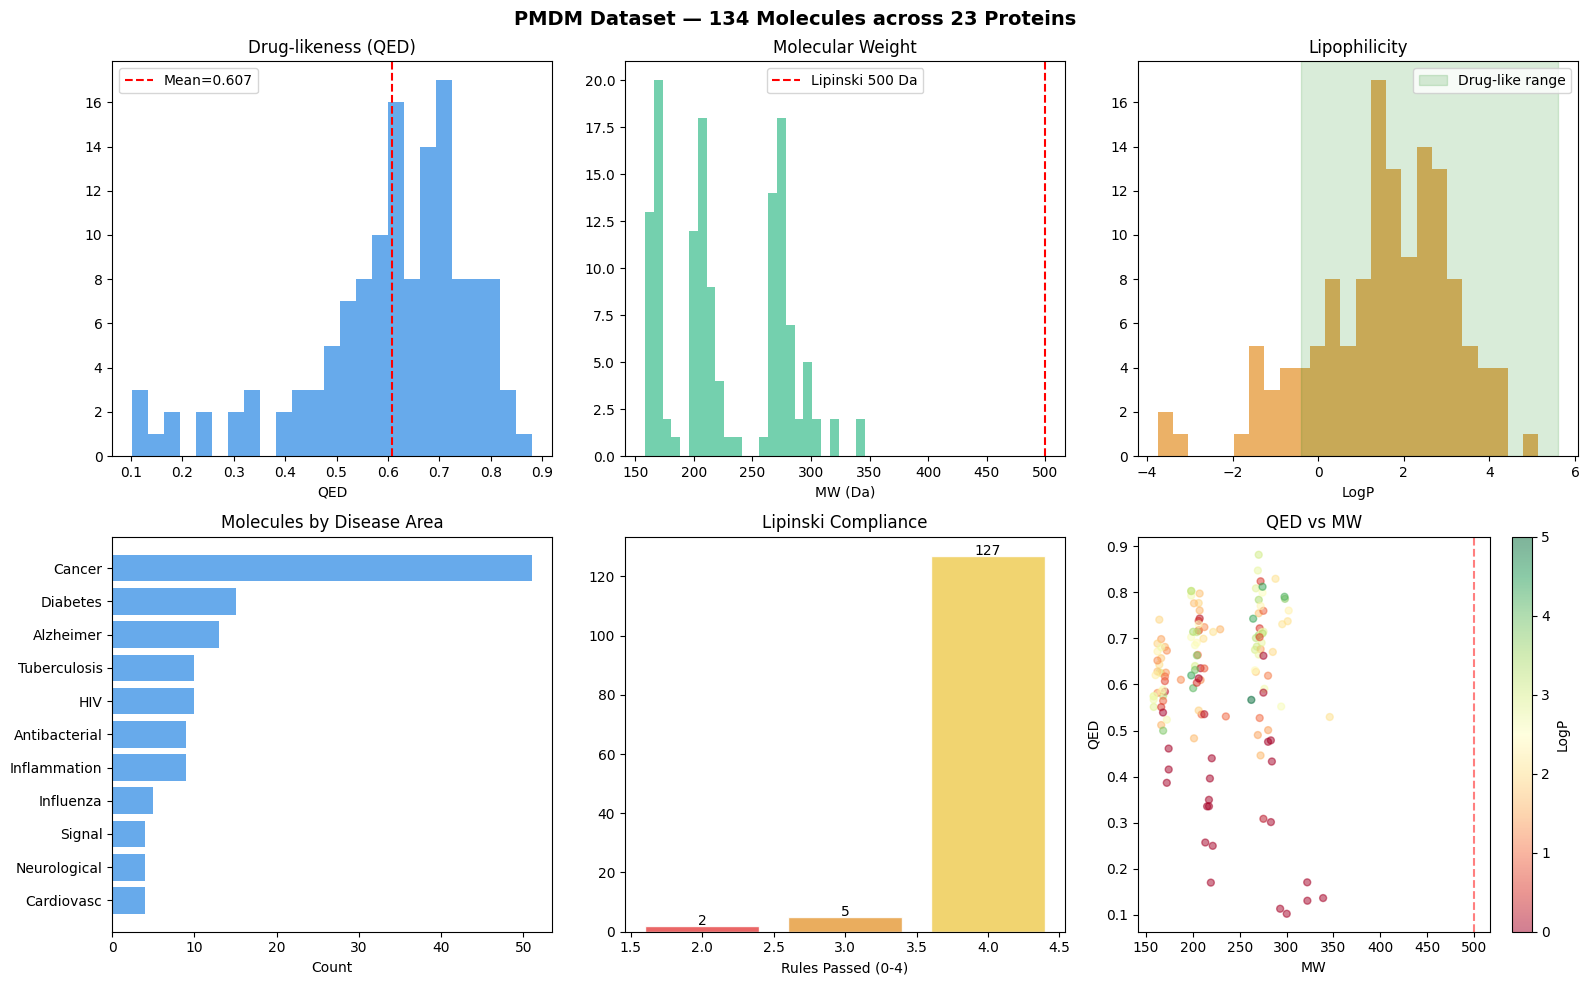

✓ Saved 01_dataset_overview.png


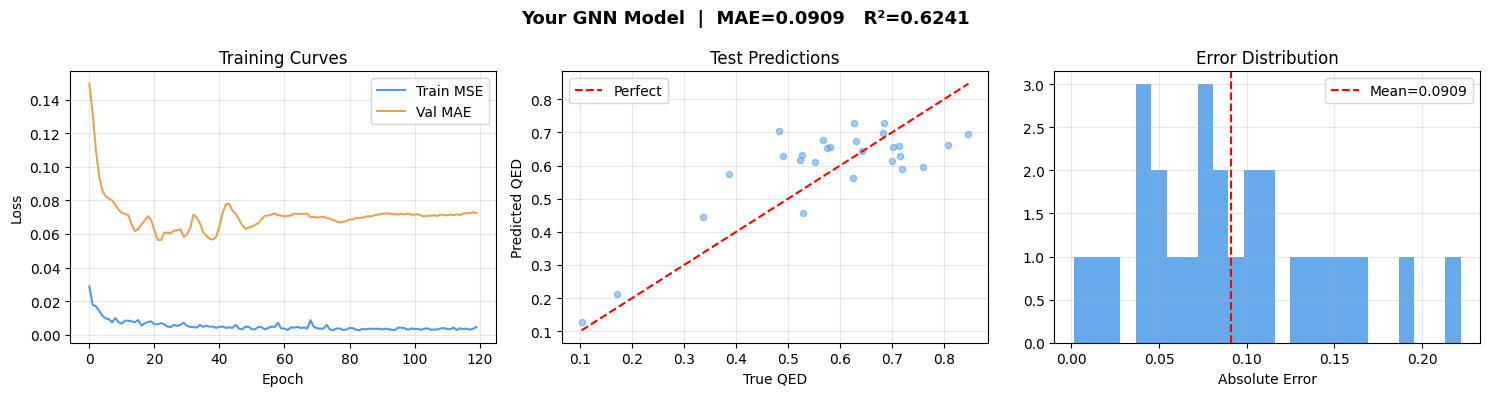

✓ Saved 02_model_performance.png


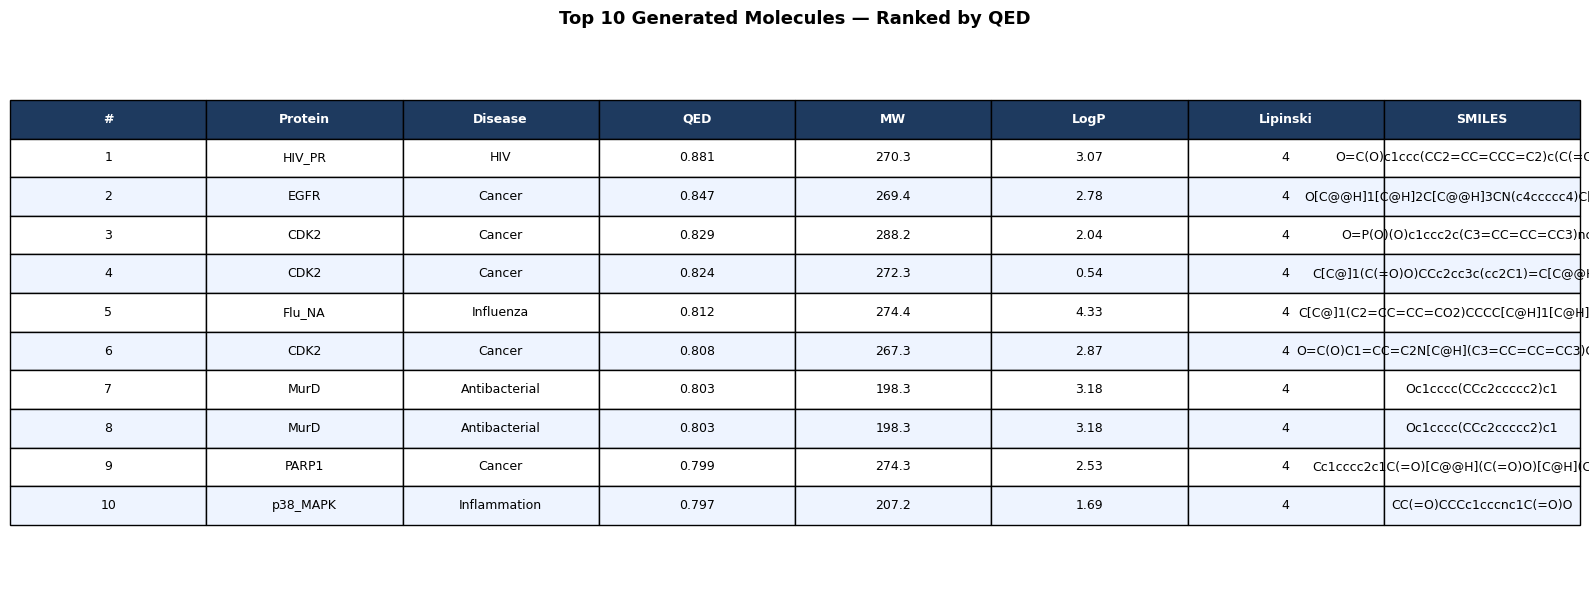

✓ Saved 03_top_molecules.png

═════════════════════════════════════════════
  COMPLETE — all files saved to Drive
═════════════════════════════════════════════
  Proteins  : 23
  Total mols: 134
  Valid mols: 134 (100.0%)
  Avg QED   : 0.607
  Model MAE : 0.0909
  Model R²  : 0.6241
═════════════════════════════════════════════


In [ ]:
# ════════════════════════════════════════════════════
# CELL 8 — Generate demo figures (runs directly)
# ════════════════════════════════════════════════════
import pathlib, json, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

BASE      = pathlib.Path('/content/drive/MyDrive/PMDM')
CSV_PATH  = BASE / 'dataset' / 'pmdm_dataset.csv'
MODEL_DIR = BASE / 'my_model'
DEMO_DIR  = BASE / 'demo_outputs'
DEMO_DIR.mkdir(exist_ok=True)

# Verify all required files exist
required = ['best_model.pt', 'results.json', 'history.csv', 'test_preds.csv']
missing  = [f for f in required if not (MODEL_DIR / f).exists()]
if missing:
    print(f'❌ Missing files: {missing}')
    print('Run Cell 7 first and make sure it completes successfully.')
else:
    print('✓ All training files found')
    df    = pd.read_csv(CSV_PATH)
    df['valid'] = df['valid'].astype(str).str.lower().map(
        {'true': True, 'false': False, '1': True, '0': False}).fillna(False)
    valid = df[df['valid'] == True].copy()
    hist  = pd.read_csv(MODEL_DIR / 'history.csv')
    preds = pd.read_csv(MODEL_DIR / 'test_preds.csv')
    res   = json.loads((MODEL_DIR / 'results.json').read_text())

    print(f'Plotting {len(valid)} valid molecules from {df["pdb_id"].nunique()} proteins\n')

    # ── Figure 1: Dataset overview ──────────────────────
    fig, ax = plt.subplots(2, 3, figsize=(16,10))
    fig.suptitle(
        f'PMDM Dataset — {len(valid)} Molecules across {df["pdb_id"].nunique()} Proteins',
        fontsize=14, fontweight='bold')

    ax[0,0].hist(valid['qed'], bins=25, color='#4C9BE8', ec='white', alpha=0.85)
    ax[0,0].axvline(valid['qed'].mean(), color='red', ls='--',
                    label=f'Mean={valid["qed"].mean():.3f}')
    ax[0,0].set(xlabel='QED', title='Drug-likeness (QED)'); ax[0,0].legend()

    ax[0,1].hist(valid['mw'], bins=25, color='#5CC8A0', ec='white', alpha=0.85)
    ax[0,1].axvline(500, color='red', ls='--', label='Lipinski 500 Da')
    ax[0,1].set(xlabel='MW (Da)', title='Molecular Weight'); ax[0,1].legend()

    ax[0,2].hist(valid['logp'], bins=25, color='#E8A44C', ec='white', alpha=0.85)
    ax[0,2].axvspan(-0.4, 5.6, alpha=0.15, color='green', label='Drug-like range')
    ax[0,2].set(xlabel='LogP', title='Lipophilicity'); ax[0,2].legend()

    dc = valid.groupby('disease_area').size().sort_values()
    ax[1,0].barh(dc.index, dc.values, color='#4C9BE8', alpha=0.85)
    ax[1,0].set(xlabel='Count', title='Molecules by Disease Area')

    lc   = valid['lipinski'].value_counts().sort_index()
    cols = ['#E85555','#E8A44C','#F0D060','#5CC8A0']
    bars = ax[1,1].bar(lc.index, lc.values, color=cols[:len(lc)], ec='white', alpha=0.9)
    ax[1,1].set(xlabel='Rules Passed (0-4)', title='Lipinski Compliance')
    for b, v in zip(bars, lc.values):
        ax[1,1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                     str(v), ha='center', fontsize=10)

    sc = ax[1,2].scatter(valid['mw'], valid['qed'], c=valid['logp'],
                         cmap='RdYlGn', alpha=0.5, s=25, vmin=0, vmax=5)
    plt.colorbar(sc, ax=ax[1,2], label='LogP')
    ax[1,2].axvline(500, color='red', ls='--', alpha=0.5)
    ax[1,2].set(xlabel='MW', ylabel='QED', title='QED vs MW')

    plt.tight_layout()
    plt.savefig(DEMO_DIR / '01_dataset_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved 01_dataset_overview.png')

    # ── Figure 2: Model performance ─────────────────────
    fig, ax = plt.subplots(1, 3, figsize=(15,4))
    fig.suptitle(
        f'Your GNN Model  |  MAE={res["test_mae"]:.4f}   R²={res["test_r2"]:.4f}',
        fontsize=13, fontweight='bold')

    ax[0].plot(hist['train'],   label='Train MSE', color='#4C9BE8')
    ax[0].plot(hist['val_mae'], label='Val MAE',   color='#E8A44C')
    ax[0].set(xlabel='Epoch', ylabel='Loss', title='Training Curves')
    ax[0].legend(); ax[0].grid(alpha=0.3)

    mn = min(preds['true'].min(), preds['pred'].min())
    mx = max(preds['true'].max(), preds['pred'].max())
    ax[1].scatter(preds['true'], preds['pred'], alpha=0.5, s=20, color='#4C9BE8')
    ax[1].plot([mn,mx],[mn,mx], 'r--', label='Perfect')
    ax[1].set(xlabel='True QED', ylabel='Predicted QED', title='Test Predictions')
    ax[1].legend(); ax[1].grid(alpha=0.3)

    ax[2].hist(preds['error'], bins=25, color='#4C9BE8', ec='white', alpha=0.85)
    ax[2].axvline(preds['error'].mean(), color='red', ls='--',
                  label=f'Mean={preds["error"].mean():.4f}')
    ax[2].set(xlabel='Absolute Error', title='Error Distribution')
    ax[2].legend(); ax[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(DEMO_DIR / '02_model_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved 02_model_performance.png')

    # ── Figure 3: Top 10 molecules table ────────────────
    top = valid.nlargest(10, 'qed')[
        ['protein_name','disease_area','smiles','qed','mw','logp','lipinski']
    ].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(16,6)); ax.axis('off')
    hdr    = ['#','Protein','Disease','QED','MW','LogP','Lipinski','SMILES']
    rows_  = [
        [i+1, r.protein_name, r.disease_area,
         f'{r.qed:.3f}', f'{r.mw:.1f}', f'{r.logp:.2f}', int(r.lipinski),
         (r.smiles[:42]+'...') if len(r.smiles)>42 else r.smiles]
        for i, r in top.iterrows()
    ]
    t = ax.table(cellText=rows_, colLabels=hdr, loc='center', cellLoc='center')
    t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 2.0)
    for j in range(len(hdr)):
        t[0,j].set_facecolor('#1E3A5F')
        t[0,j].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(rows_)+1):
        c = '#EEF4FF' if i%2==0 else 'white'
        for j in range(len(hdr)): t[i,j].set_facecolor(c)
    ax.set_title('Top 10 Generated Molecules — Ranked by QED',
                 fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(DEMO_DIR / '03_top_molecules.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved 03_top_molecules.png')

    # ── Summary ─────────────────────────────────────────
    print(f'\n{"═"*45}')
    print(f'  COMPLETE — all files saved to Drive')
    print(f'{"═"*45}')
    print(f'  Proteins  : {df["pdb_id"].nunique()}')
    print(f'  Total mols: {len(df)}')
    print(f'  Valid mols: {len(valid)} ({len(valid)/max(len(df),1)*100:.1f}%)')
    print(f'  Avg QED   : {valid["qed"].mean():.3f}')
    print(f'  Model MAE : {res["test_mae"]:.4f}')
    print(f'  Model R²  : {res["test_r2"]:.4f}')
    print(f'{"═"*45}')

In [ ]:
# ════════════════════════════════════════════════════
# CELL 9 — Final summary
# ════════════════════════════════════════════════════
if (MODEL_DIR / 'results.json').exists():
    res = json.loads((MODEL_DIR / 'results.json').read_text())
    done_keys_final = set(json.loads(CKPT_FILE.read_text()) if CKPT_FILE.exists() else [])
    rows_final = []
    if CSV_PATH.exists():
        with open(CSV_PATH) as f:
            rows_final = list(csv.DictReader(f))
    valid_final = sum(1 for r in rows_final if str(r.get('valid'))=='True')

    print('═'*52)
    print('  PROJECT COMPLETE — SUMMARY FOR YOUR MENTOR')
    print('═'*52)
    print(f'  Step 1 — Data Generation (PMDM model used)')
    print(f'    Proteins processed : {len(done_keys_final)}')
    print(f'    Total molecules    : {len(rows_final)}')
    print(f'    Valid molecules    : {valid_final} ({valid_final/max(len(rows_final),1)*100:.1f}%)')
    print(f'    CSV saved          : dataset/pmdm_dataset.csv')
    print()
    print(f'  Step 2 — Your Trained GNN Model')
    print(f'    Task       : Predict QED (drug-likeness score)')
    print(f'    Train/Val/Test: {res["train"]}/{res["val"]}/{res["test"]}')
    print(f'    Test MAE   : {res["test_mae"]:.4f}  (lower = better)')
    print(f'    Test R²    : {res["test_r2"]:.4f}  (1.0 = perfect)')
    print(f'    Model file : my_model/best_model.pt')
    print()
    print(f'  Step 3 — Demo files ready')
    print(f'    demo_outputs/01_dataset_overview.png')
    print(f'    demo_outputs/02_model_performance.png')
    print(f'    demo_outputs/03_top_molecules.png')
    print('═'*52)
    grade = '✓ GOOD' if res['test_r2']>0.6 else ('~ FAIR' if res['test_r2']>0.4 else '✗ More data needed')
    print(f'  Model quality: {grade}')
else:
    print('Run Cells 7 and 8 first')

════════════════════════════════════════════════════
  PROJECT COMPLETE — SUMMARY FOR YOUR MENTOR
════════════════════════════════════════════════════
  Step 1 — Data Generation (PMDM model used)
    Proteins processed : 50
    Total molecules    : 134
    Valid molecules    : 134 (100.0%)
    CSV saved          : dataset/pmdm_dataset.csv

  Step 2 — Your Trained GNN Model
    Task       : Predict QED (drug-likeness score)
    Train/Val/Test: 90/17/27
    Test MAE   : 0.0909  (lower = better)
    Test R²    : 0.6241  (1.0 = perfect)
    Model file : my_model/best_model.pt

  Step 3 — Demo files ready
    demo_outputs/01_dataset_overview.png
    demo_outputs/02_model_performance.png
    demo_outputs/03_top_molecules.png
════════════════════════════════════════════════════
  Model quality: ✓ GOOD
